# Advanced LLM Agents and Tools

## Agenda
* LLMs with Web Search Integration
* Agentic LLMs
* Deep Research Frameworks
* Function Calling and OpenAI Assistants
* MCP Protocols
* Prompt Engineering Techniques (Advanced)
* Evaluation and Debugging LLM Toolchains

In [1]:
!pip install openai anthropic google-generativeai langchain langchain-community langchain-core transformers huggingface_hub peft pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 183.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.8.5.post1 requires opentelemetry-api<1.27.0,>=1.26.0, but you have opentelemetry-api 1.20.0 which is incompatible.
vllm 0.8.5.post1 requires opentelemetry-sdk<1.27.0,>=1.26.0, but you have opentelemetry-sdk 1.20.0 which is incompatible.
opentelemetry-proto 1.26.0 requires protobuf<5.0,>=3.19, but you have protobuf 5.29.4 which is incompatible.


## 1. LLMs with Web Search Integration

One limitation of LLMs like GPT is that their knowledge is frozen at training time. They may lack information on recent events or specialized up-to-date facts, and they are prone to **hallucinations** when asked about things outside their knowledge. To address this, a powerful paradigm is **Retrieval-Augmented Generation (RAG)** – in particular, integrating LLMs with a live web search or another external knowledge source. In this approach, the LLM is augmented with the capability to perform search queries and retrieve relevant information, which it can then use to produce more accurate and current answers.

### 1.1 Why integrate web search?

* **Up-to-date information:** The web is continuously updated. By querying search engines or databases at runtime, an LLM can access information beyond its training cutoff date (for example, facts about events in 2023–2025). This keeps responses relevant and current.
* **Reduced hallucination:** When an LLM doesn’t know an answer, it might fabricate a plausible-sounding response. Instead, with retrieval, the model can be grounded on real data from sources like Wikipedia or news articles, leading to more factually correct answers.
* **Support and citations:** If the system provides source text to the LLM, the model can more easily cite sources or give supporting evidence for its answers. (In fact, some LLM implementations are trained to output citations when using retrieved documents.)

OpenAI’s **WebGPT** project demonstrated the effectiveness of this idea by training GPT-3 to use a text-based web browser to answer questions. The model learned to issue search queries, follow links, and even quote from webpages, and it was rewarded for citing its sources. This resulted in more accurate answers on long-form questions, with the model essentially using the web as an external memory. Microsoft’s Bing Chat (which uses GPT-4) is a production example that incorporates web search: it automatically fetches web results for user queries and integrates them into the response, often with citations.

### 1.2 Approaches to LLM + Search Integration

There are a few common patterns to integrate web search into LLM workflows:

* **In-Loop Retrieval (Agent approach):** The LLM is given the ability (via an “agent” loop) to decide when to perform a search. For example, using a prompt format like *ReAct* (which we will discuss later), the model can output an `Action: Search["..."]` with a query when it needs information, then the system executes that search and returns the results for the model to read. This loop can repeat multiple times (search -> read -> decide -> search again, etc.) until the model gathers enough information to answer.
* **Retrieval as a Preprocessing Step:** In a simpler pipeline, one can perform a search or database query *before* calling the LLM, using the user’s query to fetch relevant text, and then feed that text into the LLM’s prompt. For example, you can use a search API to retrieve the top 3 results for a question, extract the relevant snippets, and prompt the LLM: *“Using the information below, answer the question: ...”* with the snippets attached. This is sometimes called **knowledge augmentation**.
* **Plugins and Tools:** In architectures like OpenAI’s plugins or tool-use frameworks (LangChain agents, etc.), the LLM can use a predefined *search tool*. The system provides a natural-language API: e.g., a function `search(query)` that the model can call (via function calling or a specialized prompt). The model’s output is intercepted and if it “calls” the search function, the actual search is executed and results returned.

Each approach has pros and cons in terms of complexity and flexibility. A simple retrieval step is straightforward but less interactive; an agentic loop (multiple iterative searches) can handle more complex queries that require multi-hop reasoning (finding information step-by-step), at the cost of more moving parts.

### 1.3 Demonstration: Search-Augmented QA

Below is an illustrative example using **LangChain** to build a question-answering agent with web search. We will use the SerpAPI search tool (which requires an API key) to let an LLM retrieve information. If you don’t have SerpAPI, you can conceptually replace it with another search API or skip running the code. (In offline mode, this code will not execute actual web searches.)

In [1]:
import os
from langchain.agents import initialize_agent, Tool, AgentType
from langchain.llms import OpenAI
from langchain.utilities import SerpAPIWrapper

In [3]:
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ") 
os.environ["GOOGLE_API_KEY"] = getpass("Enter your Google API key: ")
os.environ['GOOGLE_CSE_ID'] = getpass("Enter your Google Custom Search Engine ID: ")

Enter your OpenAI API key:  ········
Enter your Google API key:  ········
Enter your Google Custom Search Engine ID:  ········


In [5]:
import os
from openai import OpenAI
from langchain.agents import Tool, initialize_agent, AgentType
from langchain.utilities import GoogleSearchAPIWrapper  # or any alternative like Bing, ContextualWeb


# Initialize OpenAI client (latest API version)
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Define a wrapper class to use the new OpenAI Chat API
from langchain.chat_models import ChatOpenAI

llm = ChatOpenAI(
    openai_api_key=os.environ["OPENAI_API_KEY"],
    model="gpt-4o",
    temperature=0.0,
)

# Initialize the search tool wrapper (replace with SerpAPIWrapper if needed)
search = GoogleSearchAPIWrapper()  # or BingSearchAPIWrapper, etc.

# Define tools
tools = [
    Tool(
        name="Search",
        func=search.run,
        description="Search the web for up-to-date information."
    )
]

# Create the agent
#A zero-shot ReAct agent that does a reasoning step before acting without any memory of prior turns
agent = initialize_agent(
    tools,
    llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,
)

# Ask a question
query = "Who is the president of the European Central Bank as of today and what is their professional background?"
response = agent.run(query)

print(response)



> Entering new AgentExecutor chain...
To answer this question, I need to find the most current information about the president of the European Central Bank. I will perform a web search to confirm the current president and their professional background.

Action: Search
Action Input: "current president of the European Central Bank 2023"
Observation: Christine Lagarde, President of the European Central Bank. ... 2023. The current president of the ECB is Christine Lagarde. Seated in Frankfurt, Germany, the bank formerly occupied the Eurotower prior to the ... Christine Lagarde. President of the ECB ; Luis de Guindos · Vice-President of the ECB ; Piero Cipollone · Member of the Executive Board of the ECB ; Frank Elderson. Mario Draghi – former European Central Bank President and one of Europe's great economic minds – was tasked by the European Commission to prepare a report ... Feb 16, 2023 ... ... 2023 on the European Central ... Welcomes President Lagarde's statement that the current ge

In the above:

* We defined a **Search** tool that the agent can use.
* The agent is initialized with a standard ReAct-based agent type. When we run it on a query, the LLM will determine if it needs to call the tool.
* The `verbose=True` will print the agent’s chain-of-thought. You would see something like it formulating a search query, the search results, possibly another search or reading, and finally the answer.

If you run this with valid API keys, the agent will perform a live search to find who the current ECB president is, then likely find that it’s Christine Lagarde (if the date is current to 2025, still Lagarde), and then gather background info about her (perhaps from Wikipedia), and finally respond with an answer citing her professional background (e.g., *“Christine Lagarde, a French lawyer and politician who previously served as ...”*). The exact output will depend on the retrieved content.

This demonstrates how web retrieval can be seamlessly integrated to enhance LLM responses. Retrieval-augmented techniques are widely used in production QA systems to improve accuracy and trustworthiness.


## 2. Agentic LLMs and Tool-Use Orchestration

Moving beyond single-turn Q\&A, we enter the realm of **LLM agents** – AI systems that leverage an LLM as a reasoning engine, combined with tools and memory, to autonomously perform multi-step tasks. An *agentic* LLM is one that can make decisions on what actions to take (e.g., which tool or API to call, what step to do next) in order to fulfill a high-level goal, rather than just answering a single prompt. This requires orchestrating a sequence of tool uses and intermediate reasoning steps, often dynamically.

Key aspects of an LLM-based agent include:

* **A set of tools or functions** it can use (e.g., web search, a calculator, database queries, sending emails, etc.).
* **A policy or prompting strategy** that allows the LLM to decide *which* tool to use and *when* – based on the conversation or task state.
* **Memory or state** tracking, so the agent remembers what it has done (chain-of-thought and past observations).
* **Autonomy in decision-making**, within given safety or logic constraints (the agent should know when to stop or when it has arrived at an answer).

In practice, building an LLM agent often involves a loop where the LLM produces an *action* (along with some reasoning text), the action is executed by the system, the result (observation) is fed back into the LLM, and this repeats until a final answer is produced. This is sometimes called the **Thought->Action->Observation** loop.

### 2.1 The ReAct Loop and Tool Use

One popular prompting strategy for agents is **ReAct (Reason+Act)** prompting. In this approach, the LLM is prompted to produce **Thoughts** (free-form reasoning about the problem) and **Actions** (a discrete decision, like calling a tool) in an interleaved manner. A simple example of a ReAct prompt format is:

```
You are an assistant that can think and use tools. 
Use the following tools when necessary: Search, Calculator.
Format: 
Thought: <your reasoning>
Action: <tool name>[<tool input>]
Observation: <result of tool if any>
... (loop) ...
Thought: <your reasoning>
Action: <tool name>[<tool input>] ... or Final Answer: <your answer>
```

By training or few-shot prompting the LLM in this format, we enable it to **orchestrate** complex operations. The LLM can “reason” in natural language (which we get to see, aiding interpretability) and decide to act (use a tool) when needed. For example, faced with a complex question requiring math and lookup, it might think "I should calculate this" -> use Calculator, then think "Now I need to verify something online" -> use Search, etc., and finally produce the answer.

This orchestration is the essence of making LLMs agentic. The LLM is no longer just a passive text predictor, but an agent that **interacts** with an environment (a set of tools).

### 2.2 Frameworks for LLM Agents

Several frameworks exist to help implement LLM agents without building everything from scratch:

* **LangChain Agents:** LangChain provides agent classes that implement the loop of LLM reasoning and tool use. You define the tools and the LLM; LangChain handles parsing the LLM’s output to detect actions and routing to the tool, then concatenating the observation back into the prompt for the next step.
* **Hugging Face Transformers Agents:** The 🤗 Transformers library introduced an `Agent` class that can use open-source models in an agent loop with tools from the Hugging Face Hub (for example, image classifiers, translators, etc. as tools). It uses a specific prompt format and tool registry.
* **OpenAI Function-Calling Agents:** Even without an external framework, one can use OpenAI’s function calling (see Section 5) to create a simple agent. The model can decide which function (tool) to call, return a JSON for that function, and you execute it and feed the result back.
* **Custom Loops:** For full control, you can implement your own loop: prompt the model, parse its text for an action command (you can enforce a format like `Action: <Tool>(<Input>)`), use Python to execute that, then assemble a new prompt with the observation, and so on.

### 2.3 Example: Math and Lookup Agent

To illustrate tool orchestration, let's use LangChain to set up a very simple agent with two tools: a calculator and a Wikipedia search. The agent will solve a query that requires both math and lookup.


In [8]:
from langchain.utilities import WikipediaAPIWrapper
from langchain.agents import load_tools

# Tools: math and wiki
# LangChain has a built-in calculator tool and we can use a Wikipedia wrapper
wiki = WikipediaAPIWrapper()  # tool to search and fetch summary from Wikipedia
tools = load_tools(["llm-math"], llm=llm)  # loads a calculator tool that uses Python's eval
tools.append(Tool(name="Wiki", func=wiki.run, description="Lookup information on Wikipedia."))

agent = initialize_agent(tools, llm, agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION, verbose=True)

q = "What is the year of the first manned moon landing raised to the 2nd power? Also, who was the US president at that time?"
agent.run(q)



> Entering new AgentExecutor chain...
To answer the question, I need to find the year of the first manned moon landing and the US president at that time. Then, I will calculate the square of that year.

Action: Wiki
Action Input: "first manned moon landing"

Observation: Page: Moon landing
Summary: A Moon landing or lunar landing is the arrival of a spacecraft on the surface of the Moon, including both crewed and robotic missions. The first human-made object to touch the Moon was Luna 2 in 1959.
In 1969 Apollo 11 was the first crewed mission to land on the Moon. There were six crewed landings between 1969 and 1972, and numerous uncrewed landings. All crewed missions to the Moon were conducted by the Apollo program, with the last departing the lunar surface in December 1972. After Luna 24 in 1976 there were no soft landings on the Moon until Chang'e 3 in 2013. All soft landings took place on the near side of the Moon until January 2019, when Chang'e 4 made the first landing on the far

'The year of the first manned moon landing raised to the 2nd power is 3,876,961. The US president at that time was Richard Nixon.'

In [9]:
1969**2

3876961

In the above prompt, the agent needs to figure out:

1. The year of the first manned moon landing (which is 1969, and the president then was Richard Nixon).
2. Square that year (1969^2).
3. Find who was US President in 1969.


By inspecting the `verbose` output, you could observe these steps, which is a great way to **debug the agent’s decision process**. Notice how the agent had to do multiple steps and use different tools in a sequence to answer a compound question.

This example is simplistic, but the same principle applies to more complex agent tasks (like the “deep research” agent in the next section, which uses tools repeatedly to gather and synthesize information). The combination of chain-of-thought prompting and tool use enables LLMs to handle tasks involving computation, knowledge retrieval, and even interactions with the world (like APIs or databases) in a flexible way.

## 3. "Deep Research" Pipelines with LLMs

As tasks for LLM agents become more complex, we often need to design **pipelines** where the LLM goes through multiple stages of reasoning and information gathering. A prime example (and a term used by OpenAI) is **"deep research"** – where an LLM can conduct an in-depth investigation on a topic by searching, reading multiple sources, and synthesizing a detailed report. Instead of a single prompt-response, a deep research pipeline might involve dozens of tool uses and intermediate steps autonomously handled by the agent.

OpenAI recently introduced a feature called *Deep Research* in ChatGPT for Plus users (early 2025) which showcases this capability. When you enable deep research mode and ask a complex question (for example, *“Give me a competitive analysis of the electric vehicle market in Europe”*), ChatGPT will behind the scenes operate as an agent: it will issue many web searches, follow links, read content, perhaps run some data analysis with Python, and after some time, present you with a comprehensive, cited report. This may take a few minutes as the agent systematically works through the research task, similar to how a human analyst might gather information.

### 3.1 Anatomy of a Deep Research Pipeline

A deep research pipeline typically involves the following components/stages:

1. **Question analysis and planning:** The LLM first breaks down the user’s query into sub-questions or topics to investigate. (e.g., identify key aspects like market size, key players, regulations in the EV example).
2. **Iterative retrieval:** For each sub-question, the agent performs web searches or database queries, and retrieves relevant information. This can involve multiple search queries, each reading different articles or sources.
3. **Information extraction and note-taking:** The agent reads the retrieved texts (possibly using summarization to handle long documents) and extracts the points relevant to the query. It may take notes in some structured way (perhaps stored in its conversation context or an external scratchpad).
4. **Synthesis:** After gathering sufficient information, the LLM synthesizes a coherent answer or report. This involves organizing the information, comparing and reconciling facts from different sources, and drafting the output in a logical manner.
5. **Citations and verification:** A crucial step – the agent should cite sources for each major claim (to enhance trust and allow verification). It may also double-check certain facts if there were conflicting sources.
6. **Result output:** The final answer is presented, often as a structured report (with sections, bullet points, etc.) including references.

Throughout this process, the agent maintains a **multi-step reasoning chain** and may loop back if needed (for example, if during synthesis it finds a gap, it might search again for missing info).

### 3.2 Example: Research Agent Outline

We can outline (in pseudocode) how one might implement a simplified deep-research agent using tools we’ve discussed:

```python
query = "Analyze the impact of climate change on crop yields in Southeast Asia in the last 5 years."

# Step 1: Plan
subtopics = llm_plan(f"Break the query into subtopics or steps: {query}")
# (The LLM might respond with something like: 
# 1. Key climate change indicators in Southeast Asia last 5 years 
# 2. Trends in crop yields in that period 
# 3. Evidence of climate impact on agriculture 
# 4. Specific case studies or data from countries in SE Asia)

notes = []
for topic in subtopics:
    # Step 2: Search
    results = web_search(topic)  # perform a search query (could use an API)
    # Step 3: Read & Extract
    for result in results[:3]:  # take top 3 results
        content = fetch_page_text(result.url)
        summary = llm_summarize(content, topic)
        notes.append((topic, summary, result.url))

# Step 4: Synthesis
draft_report = llm_generate_report(query, notes)
# The LLM uses all the notes (with sources) to compose a report.

# Step 5: Verification/Citations
final_report = add_citations(draft_report, notes)
print(final_report)
```

In this pseudo-code:

* `llm_plan` could be one call to an LLM (like GPT-4) prompt-engineered to list subtopics.
* `web_search` uses a search API to get result links for each subtopic.
* `fetch_page_text` would retrieve the content of a result (could use an requests or a browser API).
* `llm_summarize` is another LLM call to summarize or extract relevant info from the content with respect to the topic (to reduce text volume).
* All gathered notes (with their source URLs) are then given to `llm_generate_report` which is a final LLM call to actually write the report, including placeholders for citations.
* `add_citations` is a post-processing step (or could be part of the LLM prompt as well) to number the sources and insert them appropriately.

In practice, implementing this pipeline robustly is a challenge, especially controlling the length of context (since you might accumulate a lot of text) and ensuring the model doesn’t stray. Systems like LangChain or *BABYAGI* provide patterns for iterative refinement.

### 3.3 OpenAI's Deep Research Agent

The ChatGPT *Deep Research* mode is a closed-source example, but as described by OpenAI, it **“finds, analyzes, and synthesizes hundreds of online sources to create a comprehensive report at the level of a research analyst”**. Every claim it makes is backed by a citation, and it was specifically trained via reinforcement learning to excel at browsing tasks and multi-step reasoning. This marks a step towards more autonomous AI agents that can perform knowledge work. OpenAI’s system will even show you a sidebar of the steps it took (which websites it browsed, etc.), essentially exposing the agent’s chain-of-thought to the user.

From an implementation standpoint, OpenAI likely fine-tuned or engineered a system using GPT-4 (or a variant “o3” model) with plugins/tools for web search and Python execution, similar to how we conceptually described. They report that such an agent can solve in *tens of minutes* tasks that would take a human many hours.

### 3.4 Limitations and Considerations

* **Time and cost:** A deep research agent might run 10–50 separate LLM calls (for planning, summarizing, etc.) plus many tool calls. This can be slow and expensive with large models. It’s important to balance thoroughness with efficiency, possibly by limiting searches or using faster models for certain steps.
* **Quality control:** While an agent can gather lots of info, it might also pick up false or low-quality information if it’s not careful in choosing sources. One may need to incorporate some filtering (like preferring authoritative sources). The agent’s final synthesis is only as good as its source material and reasoning — errors can creep in if, say, it misinterprets a statistic.
* **Prompt and memory limits:** Keeping track of everything is hard. The agent must use some strategy to not exceed context limits — such as summarizing along the way (as we did with `llm_summarize`). The OpenAI deep research likely uses a combination of summarization and possibly writes to short-term memory (like storing notes outside the prompt) since it runs for up to 30 minutes.

Despite these challenges, deep research pipelines are extremely powerful for use cases like market research, academic research assistance, due diligence reports, etc. They illustrate how an LLM can go from a single-turn Q\&A system to a full *autonomous researcher* if equipped with the right tools and prompting.

## 4. Function Calling with OpenAI and Other APIs

A significant feature introduced in the OpenAI API (for models like GPT-3.5 and GPT-4) is **function calling**. This feature allows developers to define **functions** (with a name and a JSON schema for arguments) and have the model **choose** to output a JSON object calling a function when appropriate. In essence, the model can decide that instead of answering directly, it should invoke a function (for example, to retrieve information or perform a calculation), and it provides the structured data needed for that function.

Why is this important? It turns prompt-completion into a mini dialogue where the model can defer to external logic. Previously, one might prompt the model with something like: *“If the user asks for weather, respond with `weather(city)` format.”* The model might or might not follow that. With native function calling, the model’s output is guaranteed to be a well-formed JSON for one of the specified functions (when it decides to use it), which can then be programmatically executed. This bridges LLMs with traditional software more reliably.

### 4.1 Defining Functions for the Model

When using the OpenAI API, you can supply a list of function specifications in your request. Each function spec includes:

* **name:** A short identifier (no spaces) for the function.
* **description:** A natural language description of what the function does (the model sees this and it helps the model decide when to use it).
* **parameters:** A JSON Schema defining the expected arguments (their names, types, optional/required, and description for each).

For example, you might define a function for fetching weather:

```python
functions = [
    {
      "name": "get_current_weather",
      "description": "Get the current weather for a given location",
      "parameters": {
          "type": "object",
          "properties": {
              "location": {"type": "string", "description": "City name, e.g. London"},
              "unit": {"type": "string", "enum": ["celsius", "fahrenheit"]}
          },
          "required": ["location"]
      }
    }
]
```

Then, you call the chat completion with this `functions` list and `function_call="auto"` (or you can even force a particular function call). If the user asks, *“What’s the weather in London right now?”*, the model might respond with:

```json
{
  "function_call": {
    "name": "get_current_weather",
    "arguments": "{ \"location\": \"London\", \"unit\": \"celsius\" }"
  }
}
```

The API will return this as part of the model’s message (a message of role “assistant” but containing a function call). Your code can detect this and then actually call `get_current_weather(location="London", unit="celsius")` using some weather API. You then take the API’s response (say it returns *“15°C, cloudy”*) and feed it back to the model as another assistant message (or function result message). Finally, the model will produce a normal assistant message for the user, like *“The weather in London is 15°C and cloudy.”*

This pattern reliably gets the model to hand off tasks to functions when needed. It’s essentially built-in tool use for OpenAI models, without needing to do prompt hacks to get JSON.

### 4.2 Other Providers and Generalization

OpenAI’s function calling was a game changer in 2023, and other platforms have taken note:

* **Anthropic (Claude):** Claude doesn’t natively have function calling in the same way (as of 2024) – it expects pure text. However, one can imitate the behavior by prompting Claude to output a JSON or a specific format if needed. It’s just not guaranteed by the API like OpenAI’s.
* **Cohere:** Cohere’s LLM API (also text-based) doesn’t have built-in function calling either.
* **Google PaLM / Gemini:** Google’s PaLM API (text-Bison model) didn’t initially have this feature, but Google has been working on *tools*. For example, in their MakerSuite (now PaLM API), they allowed certain tools like a calculator or Google Search as special commands, and it’s likely that **Gemini** (Google’s next-gen model, which is multimodal) will incorporate a similar or expanded mechanism to call APIs. The Vertex AI “Extensions” are Google’s approach to tools, which is analogous to OpenAI’s plugins.
* **Open-source models:** While they don’t have an API-level function call, you can fine-tune or prompt an open-source model to follow a similar pattern (though not as reliably). There are libraries (like `jsonformer` or Microsoft’s `Guidance`) that help you guide a model to produce JSON of a given schema.

Function calling is not limited to “tools” like weather – it’s also used to get structured output. For instance, you could define a function `extract_contact_info` with fields name, phone, email, and ask the model to call that function to extract contact info from text. The model would then fill in the JSON. This ensures you get a structured result rather than a freeform answer, which is incredibly useful for information extraction tasks.

### 4.3 Code Example: Function Calling

Let’s demonstrate function calling with OpenAI’s library (this will run only if you have an OpenAI API key and internet access):


In [17]:
import requests

def get_weather(latitude, longitude):
    #print(latitude, longitude)
    response = requests.get(f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current=temperature_2m,wind_speed_10m&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m")
    data = response.json()
    #print(data)
    return data['current']['temperature_2m']

get_weather(41, 40)

21.8

In [19]:
from openai import OpenAI
import json



client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

tools = [{
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get current temperature for provided coordinates in celsius.",
        "parameters": {
            "type": "object",
            "properties": {
                "latitude": {"type": "number"},
                "longitude": {"type": "number"}
            },
            "required": ["latitude", "longitude"],
            "additionalProperties": False
        },
        "strict": True
    }
}]

messages = [{"role": "user", "content": "What's the weather like in Paris today?"}]


#Call model with functions defined – along with your system and user messages.
completion = client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools,
)
#Model decides to call function(s) – model returns the name and input arguments.
print(completion.choices[0].message.tool_calls)

[ChatCompletionMessageToolCall(id='call_hHfVPd3BL2xBsz0mcDsbeS63', function=Function(arguments='{"latitude":48.8566,"longitude":2.3522}', name='get_weather'), type='function')]


In [20]:
#Execute function code – parse the model's response and handle function calls.
tool_call = completion.choices[0].message.tool_calls[0]
args = json.loads(tool_call.function.arguments)

result = get_weather(args["latitude"], args["longitude"])

In [21]:
#Supply model with results – so it can incorporate them into its final response.
messages.append(completion.choices[0].message)  # append model's function call message
messages.append({                               # append result message
    "role": "tool",
    "tool_call_id": tool_call.id,
    "content": str(result)
})

#Model responds – incorporating the result in its output.
completion_2 = client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools,
)
completion_2.choices[0].message.content

'The current temperature in Paris is 15.4°C.'

## 5. MCP Protocols and Multi-Step Workflow Orchestration

As the ecosystem of LLMs and tools grows, there’s a need for standardization in how we connect models with external resources. **Model Context Protocol (MCP)** is an emerging open protocol designed to standardize how LLMs (and AI assistants) discover and use tools, data, and other resources in a multi-step workflow. The idea is to have a common framework (similar to a “USB-C for AI” as some describe) that any LLM client can use to interface with any tool provider in a consistent way.

### 5.1 What is MCP?

MCP introduces a client-server architecture:

* An **MCP Server** exposes certain capabilities (which could be functions, data sources, or even preset prompts) via the protocol.
* An **MCP Client** (which could be an LLM or an AI assistant platform) connects to these servers to utilize the exposed capabilities.
* The LLM (or an agent using an LLM) acts as a **host** that can call on multiple MCP servers as needed.

For example, one server might provide access to a database, another to a web search API, another to a code execution sandbox. The LLM can query what functions are available and call them through a standardized JSON-RPC message format. MCP handles the communication (with a defined schema for requests, responses, and errors) and even helps manage session state and context.

In essence, MCP is trying to make tool-use by LLMs **modular** and interoperable. Instead of custom hardcoded tool integrations for each project (which we often do with LangChain etc.), an MCP-compliant server can be plugged into any MCP-aware agent, and the agent can learn (perhaps from documentation) how to use it.

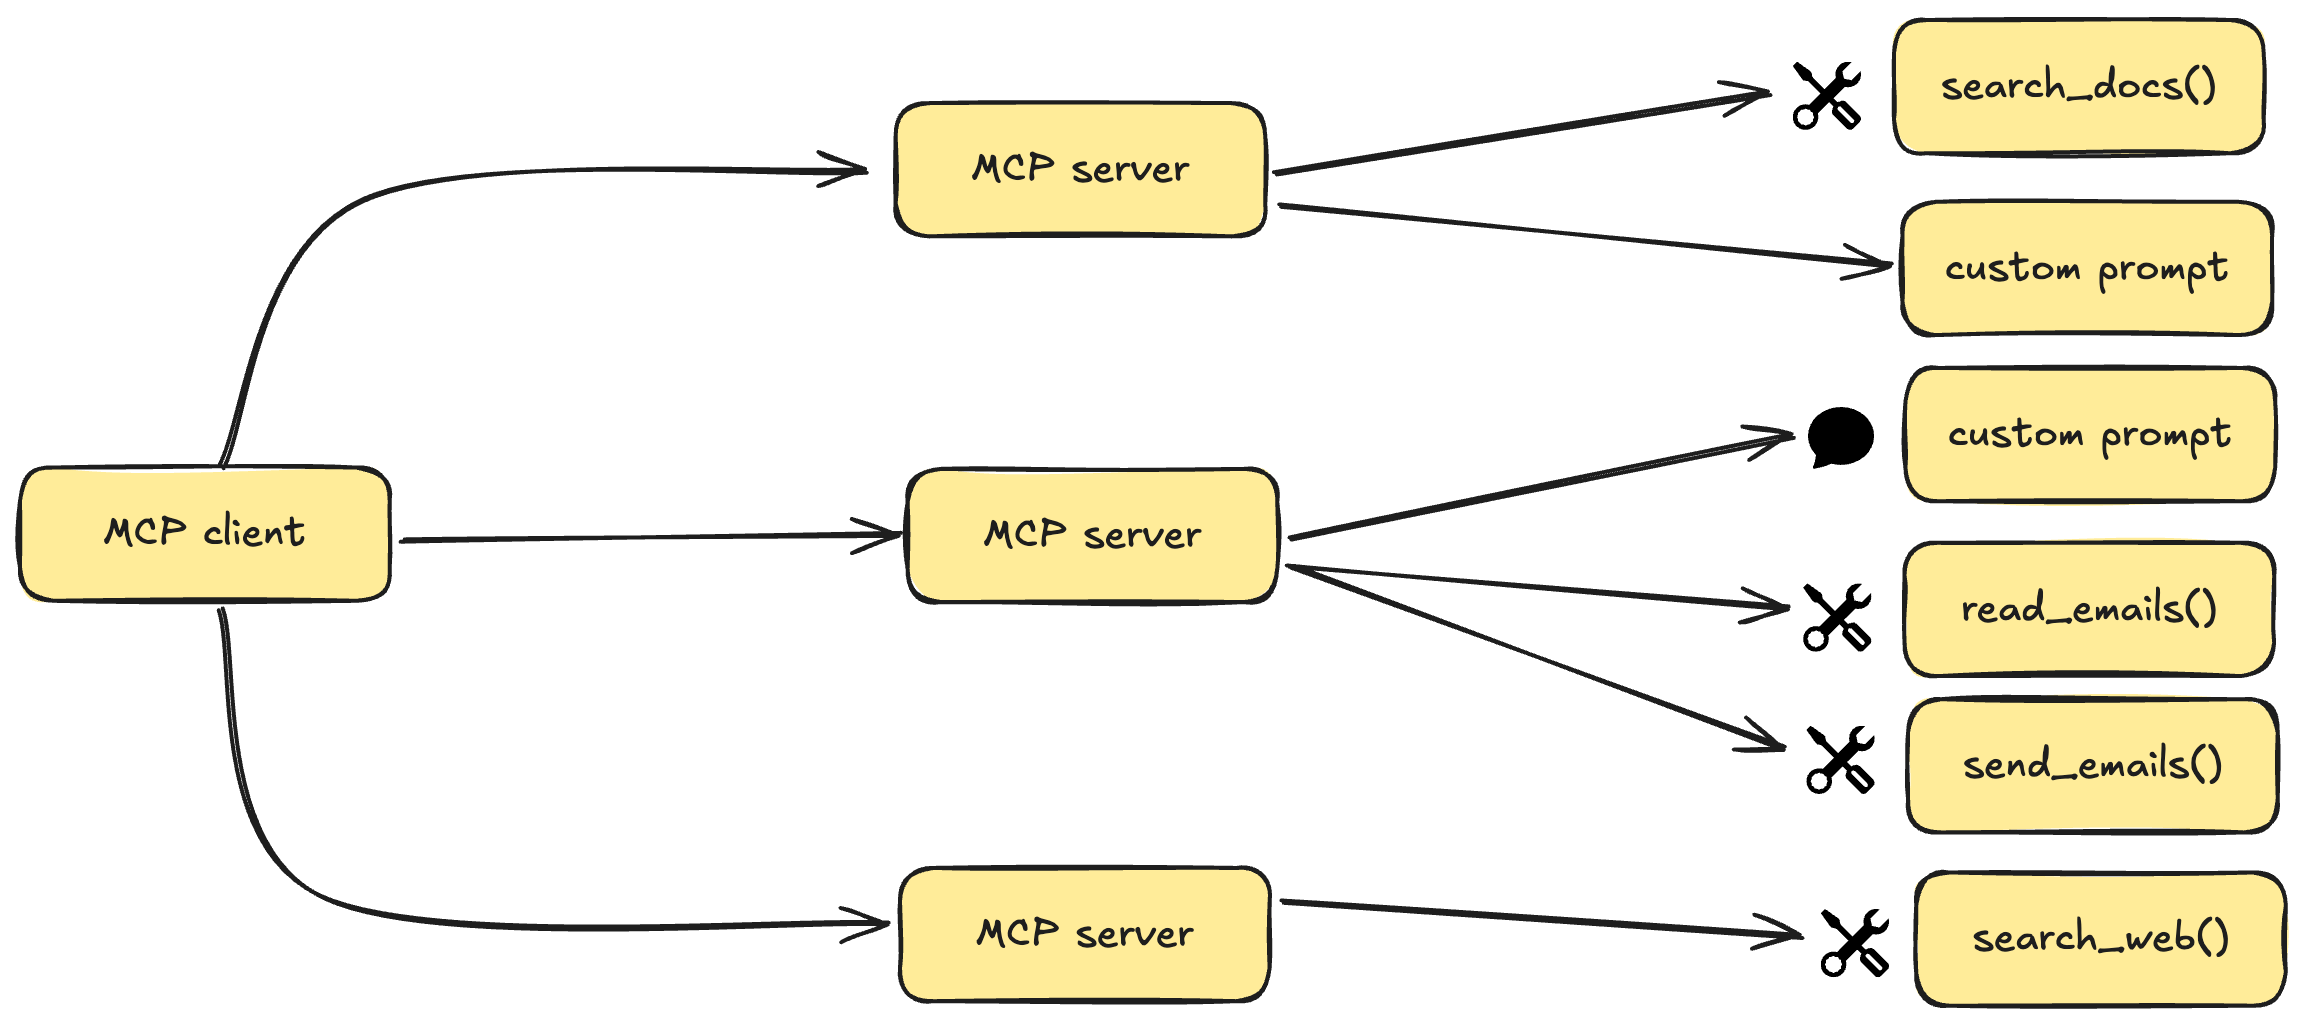

### 5.2 Example Scenario using MCP

Imagine you have an AI assistant that can do customer support tasks. You have:

* A database of customer orders.
* An API for shipment tracking.
* A knowledge base FAQ.

Without MCP, you might manually integrate these: e.g., have custom code for each that the LLM can call. With MCP, each of these could be an MCP server exposing search or query functions. The assistant (MCP client) connects to them. When a user asks: *“Where is my order #12345?”*, the assistant can:

1. Call the Orders database server via MCP to find order #12345 details (maybe it returns that it was shipped via UPS tracking #XYZ).
2. Then call the Shipping API server via MCP with that tracking number to get the latest status.
3. Then formulate an answer to the user with the information.

Throughout, the protocol ensures the calls and responses are structured (so the LLM doesn’t have to parse HTML or raw JSON - it gets clean data). The agent’s prompt at each step can include the result data (possibly converted to a friendly format or directly used).

MCP also emphasizes **security and permissions** – since servers can be local (with access to private data) or remote, the protocol fosters a controlled environment where the AI only sees what it’s meant to.

In summary, MCP is a **universal connector** that can power complex agent workflows in a robust way. As an advanced user or developer, it’s worth keeping an eye on – especially if you plan to scale up AI assistants that juggle many tools and data sources.


## 6. Advanced Prompt Engineering Techniques

By now, we have discussed various architectural components for LLM systems. Underlying many of them is the art of **prompt engineering** – designing how we ask the model to get the desired behavior. In advanced applications, it’s not just about writing a single prompt, but about guiding multi-step reasoning and leveraging the model’s stochastic nature to our advantage. We will highlight a few key techniques: **Chain-of-Thought prompting**, **ReAct prompting**, and **Self-Consistency**, among others.

### 6.1 Chain-of-Thought (CoT) Prompting

Chain-of-Thought prompting involves coaxing the model to **produce intermediate reasoning steps** before giving a final answer. Rather than answering immediately, the model is encouraged (usually via an example or an instruction like “let’s think step by step”) to break down the problem. This has been shown to significantly improve performance on complex tasks like math word problems, logic puzzles, and multi-step reasoning questions.

Example (without CoT):

* **User:** What is 18 \* 35?
* **Model (direct):** It might output “630” (which is actually incorrect; the correct is 630? Wait, 18\*35 = 630, correct actually. But on harder ones, direct might fail.)

Example (with CoT):

* **Prompt:** *“Q: What is 18 \* 35? Let’s think step by step.”*
* **Model:** “18 \* 35 is the same as 18 \* (30 + 5). 18*30 = 540, 18*5 = 90, adding gives 630. So the answer is 630.”
  It explicitly showed reasoning.

CoT helps because the model’s generation of intermediate steps helps it not to skip important considerations. It also lets us trace the reasoning. We saw CoT in action with the ReAct agent as well (the Thought steps).

For complex problems, we often use **few-shot CoT**: provide one or more examples in the prompt where the reasoning is shown. This primes the model to do the same.

However, CoT by itself doesn’t guarantee factual accuracy if knowledge is missing (the model can reason wrongly with wrong premises). That’s where retrieval or tools come in, as we covered.

CoT prompting was a breakthrough in prompting research (Wei et al., 2022), showing that even without fine-tuning, just by prompting, large models unlocked better logical reasoning.

### 6.2 ReAct Prompting (Reason + Act)

We already discussed ReAct in the agent section, but to reiterate from a prompt engineering perspective: ReAct is a *prompting technique* that interlaces the model’s Chain-of-Thought with concrete actions. It’s not a built-in feature of the model; it’s how you format the conversation.

A typical ReAct prompt might look like:

```
You are an assistant with tools.
Tools:
Search(query) - use a web search
Calculate(expression) - do calculation

Use the format:
Thought: think about problem
Action: choose one of [Search, Calculate] and provide input
Observation: (this will be given)
... (you can have multiple Thought/Action/Observation)
Thought: finally, provide answer
Answer: <your answer here>

Example:
Q: Who won the UEFA Champions League in 2020 and how many goals did the top scorer score?
Thought: The question asks for the 2020 UCL winner and top scorer's goals. I should search for "2020 UEFA Champions League winner top scorer".
Action: Search("2020 UEFA Champions League winner top scorer")
Observation: [Search results... Bayern Munich won 2020... top scorer Robert Lewandowski, 15 goals]
Thought: I have the info: Bayern Munich won and Lewandowski scored 15.
Answer: Bayern Munich won the 2020 UEFA Champions League, and the top scorer was Robert Lewandowski with 15 goals.
```

This is just a stylized prompt, but it shows how the model is guided to *alternate* between reasoning and action. The reasoning steps use natural language (which the model is good at generating in a sensible way), and the actions are very structured (so we, as the orchestrator, can detect them).

ReAct prompting significantly improved the ability of models to do things like factual lookup, because the model could literally *decide* to fetch facts rather than guess. It’s also easier to debug because you see the “Thoughts”.

### 6.3 Self-Consistency

Self-Consistency is like a “majority vote” approach applied to an LLM’s chain-of-thought. The idea, introduced by Wang et al. (2022), is:

* Instead of asking the model once with CoT, you ask it *multiple times* (with some randomness each time, e.g., by using temperature in sampling).
* You get multiple different reasoning chains and answers.
* Often, the answers might vary if some reasoning paths have mistakes. But if one answer is correct, many reasoning paths might converge to it, whereas wrong answers might be more randomly distributed.
* You then pick the answer that the model gave most frequently (or with highest total probability).

This has been found to significantly boost accuracy in reasoning tasks. Essentially, it’s leveraging the model to “double-check” itself by exploring alternatives:

* If the model tends to sometimes make a subtle error, another run might avoid that error.
* By aggregating, you cancel out some of the randomness and errors.

From a prompt engineering view, you don’t even need to change the prompt much; it’s more about the sampling strategy. But you can explicitly prompt the model to “give 3 possible solutions and then conclude” (though typically the approach is to just sample multiple independent solutions with the same prompt).

**When to use self-consistency?** When you can afford the extra computation and the task is critical or known to be tricky. For math problems, it’s great. For fact questions, it’s less useful because if the model doesn’t know a fact, 10 wrong answers won’t magically give the right answer (they might all be the same wrong answer even).

### 6.4 Other Techniques Briefly

* **Tree-of-Thoughts:** An extension where the model can branch out multiple reasoning paths and evaluate them, akin to searching a tree of possible solutions (this can improve problem-solving in puzzles).
* **Verifier or Checker prompts:** After an answer is produced, you ask the model (or a second model) to verify the answer’s correctness or follow constraints. E.g., “Now check if the above solution is correct and if not, correct it.”
* **Role-playing and Personas:** Sometimes giving the model a specific role can help. For example, “Act as a Python interpreter” can make it output just error messages and nothing else when evaluating code. We implicitly use this when we set system prompts for the model’s identity.
* **OpenAI’s System / Developer messages:** Using the system message to enforce a style or policy (like “Always answer with JSON.”) is a form of prompt engineering too. It’s somewhat more baked-in with ChatCompletion API, but it’s effectively a prompt.


### 6.5 Using ReAct/CoT in practice

In practice, frameworks like LangChain automate some prompt engineering:

* When you use `AgentType.ZERO_SHOT_REACT_DESCRIPTION`, LangChain is injecting a prompt similar to the ReAct example earlier, including tool descriptions and the expected format.
* For CoT, you might manually add “Think step by step” in user prompts or use few-shot examples.

OpenAI’s own documentation cautions that the model might not always follow “let’s think step by step” if not already inclined to, but usually for sufficiently large models it works.

One must be careful: exposing chain-of-thought to users (like showing the reasoning) can sometimes leak confidential info or be verbose. Typically, CoT is used internally (the model produces the reasoning but only the final answer is shown to the user).

**Self-consistency trade-off:** It uses more tokens/inferences. If each solve is independent, you pay multiple times. But it can be parallelized since each attempt doesn’t depend on others until the vote.

To wrap up:
Advanced prompting is like **teaching the model how to think**, not just what to answer. By nudging it to articulate its reasoning and by cleverly aggregating multiple attempts, we can significantly improve reliability and accuracy of LLM responses. These techniques are crucial when building systems that need a high degree of correctness, such as in mathematical problem solvers or complex decision-making assistants.

## 7. Evaluation and Debugging of LLM-Based Toolchains

Building an LLM agent or tool-augmented system is one thing; ensuring it works reliably is another. Because of the complexity (model reasoning, tool outputs, multi-step state), these systems can fail in non-obvious ways. In this section, we discuss how to **evaluate** such systems and debug them to improve performance.

### 7.1 Evaluation Strategies

**Traditional evaluation** for static QA models uses accuracy, F1 scores, etc., on a dataset of question-answer pairs. For agents, especially ones that use tools, we need to assess:

* **Final Answer Quality:** Does the agent ultimately produce the correct or desired result for the user? This can be measured via accuracy if there’s a known answer, or via human ratings for open-ended tasks.
* **Step-wise Performance:** Since the agent performs multiple steps (retrieval, calculations, API calls), we should evaluate those steps individually:

  * Did it retrieve relevant documents (if using RAG)? (Precision/Recall of retrieved info)
  * Did it choose the appropriate tool for each sub-task?
  * Was the tool execution successful? (E.g., code ran without errors, or API returned expected data)
  * Did the agent correctly interpret the tool’s output?
  * How many steps did it take – was it efficient or taking a long, looping path?

To facilitate this, one can instrument the agent to log its chain-of-thought and actions. This log can then be analyzed:

* For **success cases**, see what went right.
* For **failure cases**, pinpoint where it went wrong: Did it choose the wrong tool? Did it hallucinate some info instead of using the tool? Did it loop?

Arize AI suggests building **evaluators for each skill** of the agent. For example, have a set of test queries where you know which tool should be used. Then check if the agent indeed used that tool. Or if it’s supposed to call a function with certain arguments (given a known input), check if it did.

There’s also the notion of **Agent-specific metrics**:

* **Tool usage count:** how many tool calls on average per query? (Too many might indicate inefficiency.)
* **Fraction of queries where agent had to backtrack or correct itself:** e.g., it got an error and then tried something else. This can be a measure of robustness.

If you have an agent in production, you might track user feedback or outcomes. For instance, if it’s an e-commerce assistant agent:

* Success could be measured by whether the user found what they wanted or completed a purchase.
* If the agent fails (user says “this is wrong” or disengages), capture those cases for debugging.

### 7.2 Debugging Techniques

**1. Reproduce and analyze:** When you find a problematic case, run the agent with verbose logging. Go through the Thought/Action sequence. Because the chain-of-thought is often in natural language, you can usually understand what the model was “thinking” and where that might be illogical or based on a false assumption.

For example, if the agent decided to Search for something irrelevant, maybe your prompt hints were not strong enough about what to search for, or it didn’t understand the user query correctly.

**2. Check the prompts/system messages:** Many issues can be fixed by refining the instructions:

* If the agent tends to hallucinate an answer without using a tool, you might reinforce in the system prompt: *“If the question requires external information not provided, you **must** use the search tool before answering.”*
* If it picks the wrong function, maybe adjust the function descriptions to be clearer or more distinct.

**3. Limit the action space if needed:** If an agent often uses a tool unhelpfully, perhaps remove that tool or restrict its usage via code (e.g., allow only one call of a certain type per query). This is a brute-force but sometimes effective debugging method.

**4. Simulate edge cases:** Think of ways the agent could mess up:

* Could it enter an infinite loop? (E.g., it keeps searching and never stops.) To handle that, implement a step counter and break if exceeding a threshold, then have a fallback answer (or prompt the model that it has done too many steps).
* Could it call a function with wrong arguments? Possibly, yes. To handle that, you might validate inputs (if not already validated by function schema in OpenAI) and either correct them or have the model handle the error. For instance, if a tool returns an error or empty result, have the agent observe “Observation: Tool returned no results” – does it then try something else appropriately? If not, you might need to add training data or prompt tuning for such cases.

**5. Use automated eval tools:** There are some libraries (like `promptfoo`, `langchain` evaluation module, or `OpenAI Evals`) that help create test cases and run the agent through them. They can check if outputs match expected results or use LLM-based evaluators to score quality.

**6. Evaluate in parts:** Evaluate the tool sub-system alone. For example, test your search function separately (is it returning good snippets?). Or test the LLM alone on some reasoning if it had the info. This isolation can tell you if the problem is with the LLM’s decision-making or with the tool outputs.

**7. Monitoring in deployment:** If your agent is live, put in logging for unusual events:

* If the agent hits the step limit often, log those conversations to examine later.
* If an API call fails (exception), log that and possibly what the model attempted to do.

**8. Agent Reflection (research idea):** Recently, a technique involves letting the agent reflect on its own output. For instance, after solving, ask the model, “Were you correct? If not, where did you go wrong?” and sometimes it might catch its own mistake. This is experimental but interesting.

In debugging, one often finds it’s a balancing act:

* Tightening instructions to fix one issue can cause the agent to become too rigid somewhere else.
* Giving the model more freedom can improve creativity but lead to occasional wild behavior.

Continuous evaluation (using a mixture of automated tests and occasional human review of random samples) is important. It’s like testing software – you need unit tests (evaluate each step) and integration tests (the whole agent on realistic tasks).

Arize’s advice was to “pinpoint where an agent is struggling” by checking each component. For example, if final answers are wrong but you see it always retrieved the right info, then the issue is in synthesis – maybe the prompt for using the retrieved info could be improved, or the model is ignoring it (some models have a tendency to hallucinate even when info is present; you might need to explicitly say “only use the provided info”).